# Leaderboard - VG_Recommender
Lee experiment_results.json y muestra todos los resultados ordenados por R2.
Ejecutar despues de correr cualquier notebook de regresion.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from results_tracker import load_results, print_leaderboard
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print_leaderboard()



LEADERBOARD  VG_Recommender
ID                Modelo   R2 test  RMSE test            R2 TSCV         R2 KFold   Emb
05         RS + Metadata    0.7922    25.9374    0.4074 ± 0.6532  0.4648 ± 0.2077 clean
09      RS + Review Text    0.7857    26.3384    0.8719 ± 0.0578  0.5475 ± 0.4724 clean
10   RS + Reviews + RAWG    0.6750    32.4362    0.7616 ± 0.1524  0.5121 ± 0.5914 clean
08 Hybrid Collab-Content    0.5629    37.6141    0.1608 ± 1.1759  0.4109 ± 0.2354 clean
03    RS Embeddings Only    0.5439    38.4240    0.6163 ± 0.4712  0.3530 ± 0.2888 clean
04         Metadata Only    0.0113    56.5711   -0.3956 ± 0.5587  0.0695 ± 0.0720  none
06       Review Text Emb   -0.0200    57.4604   -0.3001 ± 0.1819 -0.0623 ± 0.1310  none
07        Tag Embeddings -174.9966    76.2519 -30.8344 ± 35.0873 -0.0828 ± 0.1176  none



In [2]:
df = load_results()

if df.empty:
    print('Sin resultados. Ejecuta algun notebook de regresion primero.')
else:
    cols = [c for c in ['ID','Modelo','Features','Emb','R2 test','RMSE test','MAE test','MAPE test %','R2 TSCV','R2 KFold','Notas'] if c in df.columns]
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 240)
    pd.set_option('display.max_colwidth', 45)
    display(df[cols])


,ID,Modelo,Features,Emb,R2 test,RMSE test,MAE test,MAPE test %,R2 TSCV,R2 KFold,Notas
0,05,RS + Metadata,RS clean (64d) + Metadata (6d),clean,0.7922,25.9374,4.9404,0.4862,0.4074 ± 0.6532,0.4648 ± 0.2077,
1,09,RS + Review Text,RS clean (64d) + Review text (384d),clean,0.7857,26.3384,3.3445,29.6479,0.8719 ± 0.0578,0.5475 ± 0.4724,"cutoff=2016-01-01, train=2621, test=486"
2,10,RS + Reviews + RAWG,RS clean (64d) + Review text (384d) + RAW...,clean,0.6750,32.4362,3.6365,30.5803,0.7616 ± 0.1524,0.5121 ± 0.5914,"Ablation: RS=0.9071, 09=0.5648, full=0.6750"
3,08,Hybrid Collab-Content,RS clean (64d) + TF-IDF (100d) + Numeric ...,clean,0.5629,37.6141,5.5317,0.4387,0.1608 ± 1.1759,0.4109 ± 0.2354,
4,03,RS Embeddings Only,RS clean (64d),clean,0.5439,38.4240,5.8174,0.4842,0.6163 ± 0.4712,0.3530 ± 0.2888,
5,04,Metadata Only,Metadata (6d),none,0.0113,56.5711,19.8431,8.3484,-0.3956 ± 0.5587,0.0695 ± 0.0720,
6,06,Review Text Emb,Review text (384d),none,-0.0200,57.4604,15.9330,6.1708,-0.3001 ± 0.1819,-0.0623 ± 0.1310,
7,07,Tag Embeddings,Tag embeddings (384d),none,-174.9966,76.2519,14.5666,4.4811,-30.8344 ± 35.0873,-0.0828 ± 0.1176,


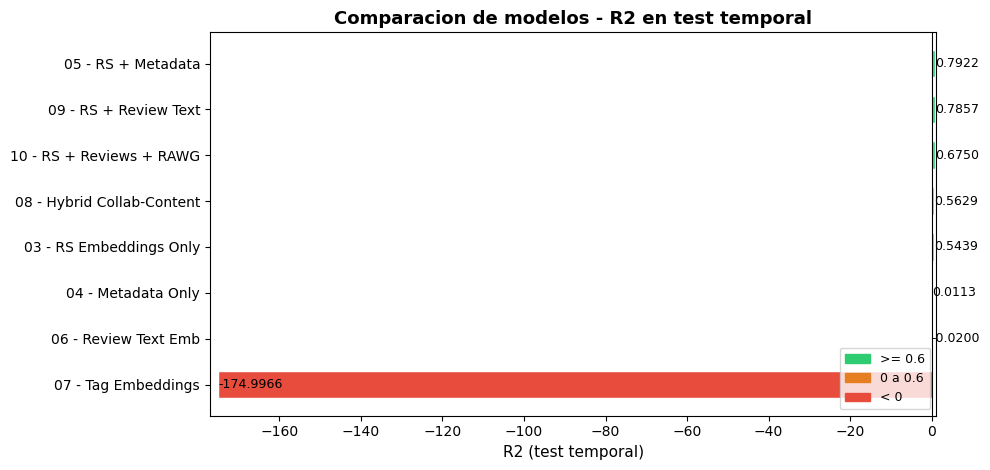

In [3]:
# Grafico comparativo R2
df = load_results()
if not df.empty:
    df_plot = df.dropna(subset=['R2 test']).sort_values('R2 test')
    labels  = df_plot['ID'] + ' - ' + df_plot['Modelo']
    r2_vals = df_plot['R2 test'].values
    colors  = ['#2ecc71' if v >= 0.6 else '#e67e22' if v >= 0 else '#e74c3c' for v in r2_vals]

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_plot) * 0.6)))
    bars = ax.barh(labels, r2_vals, color=colors, edgecolor='white', height=0.6)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('R2 (test temporal)', fontsize=11)
    ax.set_title('Comparacion de modelos - R2 en test temporal', fontsize=13, fontweight='bold')
    ax.set_xlim(min(r2_vals) - 2, 1.1)
    patches = [mpatches.Patch(color='#2ecc71', label='>= 0.6'),
               mpatches.Patch(color='#e67e22', label='0 a 0.6'),
               mpatches.Patch(color='#e74c3c', label='< 0')]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()


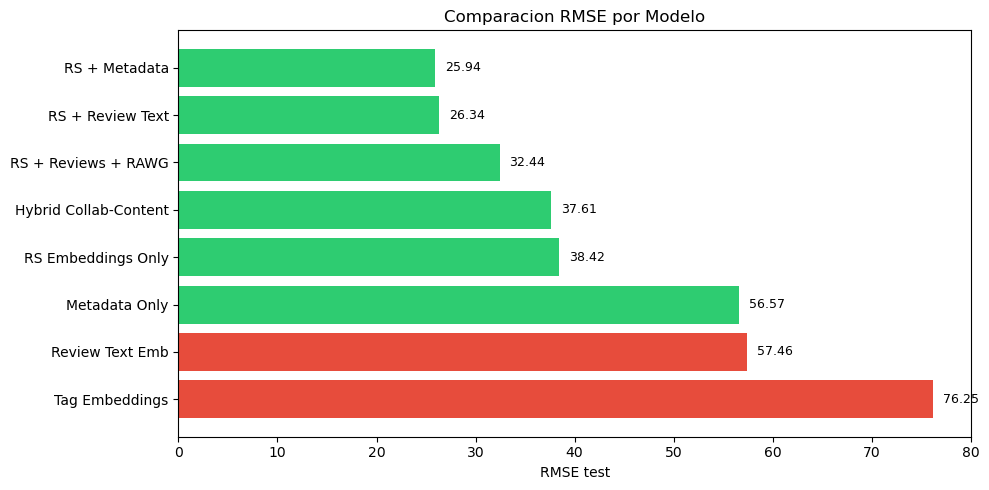

In [4]:
# Grafico RMSE (menor es mejor)
import matplotlib.pyplot as plt
import numpy as np
df = load_results()
if not df.empty:
    df_plot = df.dropna(subset=["RMSE test"]).sort_values("RMSE test")
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#2ecc71" if r > 0 else "#e74c3c" for r in df_plot["R2 test"]]
    bars = ax.barh(df_plot["Modelo"], df_plot["RMSE test"], color=colors)
    for bar, val in zip(bars, df_plot["RMSE test"]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=9)
    ax.set_xlabel("RMSE test")
    ax.set_title("Comparacion RMSE por Modelo")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


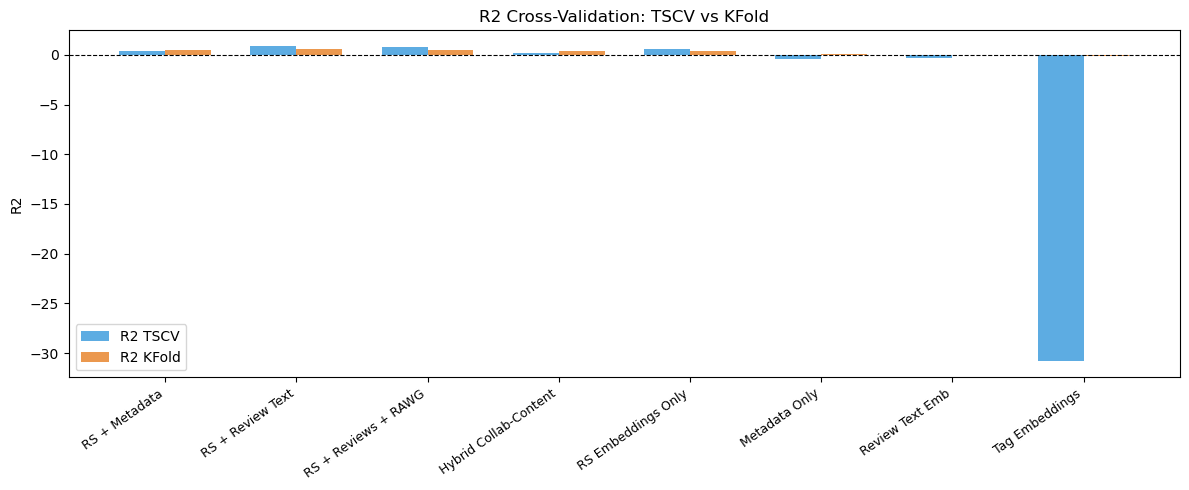

In [5]:
# R2 TSCV vs KFold
import re
df = load_results()
if not df.empty:
    df2 = df.copy()
    def extract_mean(v):
        if isinstance(v, (int, float)):
            return float(v)
        m = re.match(r"([+-]?[\d.]+)", str(v))
        return float(m.group(1)) if m else float("nan")
    df2["r2_tscv_num"]  = df2["R2 TSCV"].apply(extract_mean)
    df2["r2_kfold_num"] = df2["R2 KFold"].apply(extract_mean)
    df_plot = df2.dropna(subset=["r2_tscv_num","r2_kfold_num"]).sort_values("R2 test", ascending=False)
    x = np.arange(len(df_plot))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, df_plot["r2_tscv_num"],  width, label="R2 TSCV",  color="#3498db", alpha=0.8)
    ax.bar(x + width/2, df_plot["r2_kfold_num"], width, label="R2 KFold", color="#e67e22", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["Modelo"], rotation=35, ha="right", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("R2")
    ax.set_title("R2 Cross-Validation: TSCV vs KFold")
    ax.legend()
    plt.tight_layout()
    plt.show()


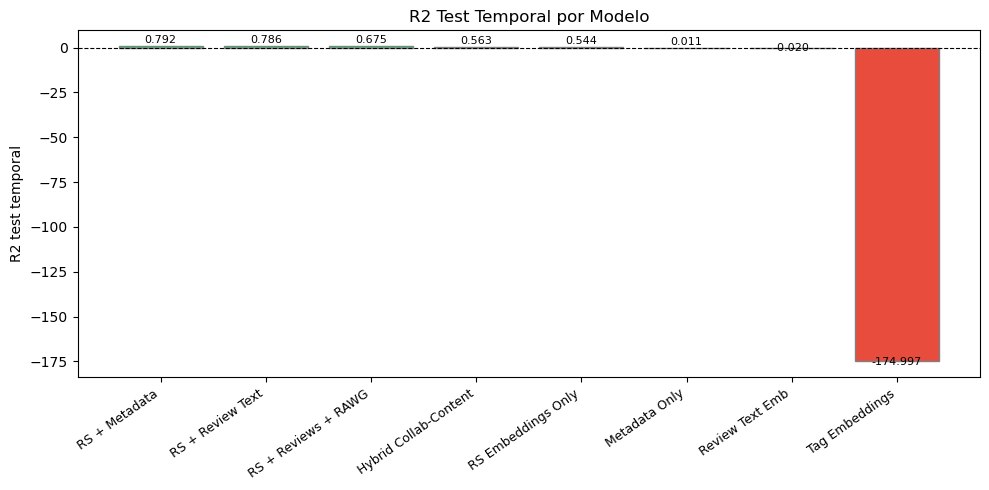

In [6]:
# R2 por modelo (test temporal)
df = load_results()
if not df.empty:
    df_plot = df.dropna(subset=["R2 test"]).sort_values("R2 test", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#2ecc71" if r > 0 else "#e74c3c" for r in df_plot["R2 test"]]
    bars = ax.bar(df_plot["Modelo"], df_plot["R2 test"], color=colors, edgecolor="grey")
    for bar, val in zip(bars, df_plot["R2 test"]):
        ypos = val + 0.5 if val >= 0 else val - 3
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f"{val:.3f}",
                ha="center", va="bottom", fontsize=8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("R2 test temporal")
    ax.set_title("R2 Test Temporal por Modelo")
    plt.xticks(rotation=35, ha="right", fontsize=9)
    plt.tight_layout()
    plt.show()
